# GNN for edge classification to link the tracksters

Here, we will create an Edge classification graph that will link the tracksters belonging to the same particle. We will have the following properties:
1. Nodes: Tracksters
2. Node features: Trackster features
3. True label: From Associations tree
4. Edge features: .....

## Extracting data for all particles

In [1]:
import uproot
import awkward as ak
import numpy as np

In [2]:
particle_files={
    "n":"flat_tree_for_Neutron.root",
    "p":"flat_tree_for_Proton.root",
    "Y":"flat_tree_for_Photon.root",
    "pi0":"flat_tree_for_pion0.root",
    "pi+":"flat_tree_for_pion.root"
}
particle_ids={
    "n":0,
    "p":1,
    "Y":2,
    "pi0":3,
    "pi+":4
}

In [53]:
%%time
all_events=[]
all_labels=[]
for pname,file_path in particle_files.items():
    file=uproot.open(file_path)
    #opening the trees
    reco=file["ticlDumper/CLUE3DHighTree"].arrays(library="ak")[:1000]
    sim=file["ticlDumper/SimTrackstersTree"].arrays(library="ak")[:1000]
    assoc=file["ticlDumper/associations"].arrays(library="ak")[:1000]
    simTICL=file["ticlDumper/simTICLCandidate"].arrays(library="ak")[:1000]
    #Particle-IDs
    pid=particle_ids[pname]
    n_events=len(reco)
    all_events.extend([
        (
            {
                "reco":reco[i],
                "sim":sim[i],
                "assoc":assoc[i],
                "simTICL":simTICL[i]
            },
            pid
        )
        for i in range(n_events)
    ])

CPU times: user 2min 10s, sys: 15.1 s, total: 2min 25s
Wall time: 2min 52s


In [54]:
len(all_events)

5000

In [61]:
all_events[1000][0]["reco"]

<Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>

In [62]:
all_events[0:5]

[({'reco': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
   'sim': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
   'assoc': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
   'simTICL': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>},
  0),
 ({'reco': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
   'sim': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
   'assoc': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
   'simTICL': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>},
  0),
 ({'reco': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
   'sim': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
   'assoc': <Record {run_: 1, luminosityBlock_: 1, 

In [69]:
all_events[0][0]['reco']

<Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>

### Shuffling

In [74]:
from sklearn.utils import shuffle
all_events=shuffle(all_events,random_state=28)

In [77]:
sample=all_events[1]
event,pid=sample

In [79]:
event

{'reco': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
 'sim': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
 'assoc': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>,
 'simTICL': <Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>}

In [78]:
pid

4

In [80]:
reco_dat=event["reco"]

In [82]:
reco_dat["barycenter_x"]

<Array [43.5, 33.5, 32.8, 38.1, ..., -34.5, -29.6, -33.3] type='15 * float32'>

## Extracting the graph features

### Getting the node features

The tracksters are the nodes and the node features are the characteristics of the tracksters

In [83]:
def get_node_features(event):
    
    feats=np.stack([
        event["time"],
        event["raw_energy"],
        event["raw_em_energy"],
        event["raw_pt"],
        event["barycenter_x"],
        event["barycenter_y"],
        event["barycenter_z"],
        event["barycenter_eta"],
        event["barycenter_phi"],
        event["EV1"],
        event["EV2"],
        event["EV3"],
        event["sigmaPCA1"],
        event["sigmaPCA2"],
        event["sigmaPCA3"]
    ],axis=1)
    
    return np.array(feats)

In [96]:
#Testing
test_sample=all_events[99]
event,pid=test_sample
reco=event['reco']
node_features=get_node_features(reco)
node_features.shape

(52, 15)

### Building the graph edges

In [ ]:
from sklearn.neighbors import NearestNeighbors

def build_edges(event,k=8):
    x=np.array(event["barycenter_x"])
    y=np.array(event["barycenter_y"])
    z=np.array(event["barycenter_z"])
    coords=np.stack([x,y,z],axis=1)
    # Fit KNN-determine the KNN
    n_nodes=len(coords)
    k_eff=min(k,n_nodes-1)
    if n_nodes<2:
        return np.empty((2,0),dtype=int)
    knn=NearestNeighbors(n_neighbors=k_eff+1,algorithm='auto').fit(coords)
    dist,idx=knn.kneighbors(coords)
    #Creating edges
    edges=[]
    for i,nbrs in enumerate(idx):
        for j in nbrs[1:]:
            edges.append([i,j])
    edges=np.array(edges).T
    return edges

In [90]:
def build_edges(event):
    x=np.array(event["barycenter_x"])
    n_nodes=len(x)
    if n_nodes<2:
        return np.empty((2,0),dtype=int)
    #Creating the pairs of source and destination
    src=[]
    dst=[]
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i!=j:
                src.append(i)
                dst.append(j)
    edge_index=np.array([src,dst],dtype=int)
    return edge_index

In [93]:
#Testing
test_sample=all_events[99]
event,pid=test_sample
reco=event['reco']
edge_index=build_edges(reco)
edge_index.shape

(2, 2652)

In [97]:
src,dst=edge_index

In [102]:
print(src)

[ 0  0  0 ... 51 51 51]


### Build Edge Features

In [103]:
def build_edge_features(event,edge_index):
    x=np.array(event["barycenter_x"])
    y=np.array(event["barycenter_y"])
    z=np.array(event["barycenter_z"])
    eta=np.array(event["barycenter_eta"])
    phi=np.array(event["barycenter_phi"])
    t=np.array(event["time"])
    E=np.array(event["raw_energy"])
    
    features=[]
    
    for i,j in edge_index.T:
        dx=x[i]-x[j]
        dy=y[i]-y[j]
        dz=z[i]-z[j]
        dist=np.sqrt(dx*dx+dy*dy+dz*dz)
        deta=eta[i]-eta[j]
        dphi=phi[i]-phi[j]
        dt=t[i]-t[j]
        dE=E[i]-E[j]
        features.append([dist,dz,deta,dphi,dt,dE])
    return np.array(features)

In [104]:
#Testing
test_sample=all_events[99]
event,pid=test_sample
reco=event['reco']
node_features=get_node_features(reco)
edge_index=build_edges(reco)
edge_features=build_edge_features(reco,edge_index)

In [106]:
edge_index.shape
edge_features.shape

(2652, 6)

### Getting the truth mappings

#### Choosing the threshold

(array([7.20056598e+18, 4.80037697e+18, 3.60028273e+18, 0.00000000e+00,
        1.20009442e+18, 1.20009406e+18, 1.20009406e+18, 0.00000000e+00,
        1.20009477e+18, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 2.40018954e+18, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 2.40018954e+18, 0.00000000e+00,
        2.40018954e+18, 1.20009477e+18, 0.00000000e+00, 0.00000000e+00,
        1.20009194e+18, 1.20009477e+18, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.20009477e+18,
        2.40018954e+18, 1.20009477e+18, 0.00000000e+00, 0.00000000e+00,
        1.20009477e+18, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.20009760e+18,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000000

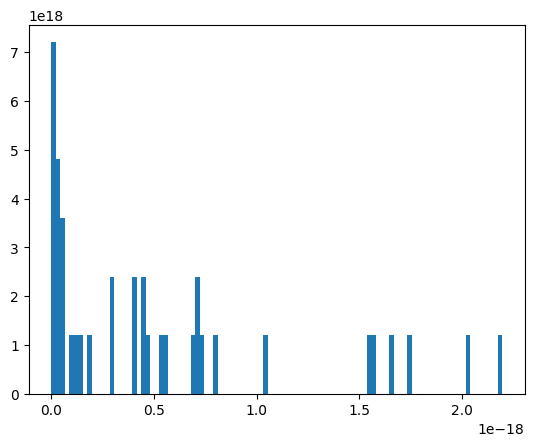

In [177]:
test_sample=all_events[99]
event,pid=test_sample
assoc=event["assoc"]
simTICL=event["simTICL"]
reco_to_sim=ak.flatten(assoc["CLUE3DHigh_recoToSim_CP"])
sharedE=ak.flatten(assoc["CLUE3DHigh_recoToSim_CP_score"])
sim_energy=simTICL["simTICLCandidate_raw_energy"]
ratio=ak.to_numpy(sharedE/sim_energy[reco_to_sim])
mask=ratio>0.0
plt.hist(ratio[mask],bins=100,density=True)
#plt.yscale("log")

In [179]:
print(ak.sum(np.isnan(ratio)))
print(ak.sum(~np.isnan(ratio)))

0
52


In [111]:
def get_truth_mappings(event,threshold=0.3):
    assoc=event["assoc"]
    simTICL=event["simTICL"]
    reco_to_sim=assoc["CLUE3DHigh_recoToSim_CP"]
    sharedE=assoc["CLUE3DHigh_recoToSim_CP_score"]
    sim_energy=simTICL["simTICLCandidate_raw_energy"]
    truth={}
    for i,matches in enumerate(reco_to_sim):
        if len(matches)==0:
            truth[i]=-1
            continue
        score=sharedE[i]/sim_energy[matches]
        best_idx=int(np.argmax(score))
        best_score=score[best_idx]
        if best_score>threshold:
            truth[i]=int(matches[best_idx])
        else:
            truth[i]=-1
    return truth

In [114]:
#Testing
test_sample=all_events[10]
event,pid=test_sample
reco=event['reco']
node_features=get_node_features(reco)
edge_index=build_edges(reco)
edge_features=build_edge_features(reco,edge_index)
truth=get_truth_mappings(event)

In [115]:
truth

{0: -1,
 1: -1,
 2: -1,
 3: -1,
 4: -1,
 5: -1,
 6: -1,
 7: -1,
 8: -1,
 9: -1,
 10: -1,
 11: -1,
 12: -1,
 13: -1,
 14: -1,
 15: -1,
 16: -1,
 17: -1,
 18: -1,
 19: -1,
 20: -1,
 21: -1,
 22: -1,
 23: -1,
 24: -1,
 25: -1,
 26: -1,
 27: -1,
 28: -1,
 29: -1,
 30: -1,
 31: -1,
 32: -1,
 33: -1,
 34: -1,
 35: -1,
 36: -1,
 37: -1,
 38: -1,
 39: -1,
 40: -1,
 41: -1,
 42: -1,
 43: -1,
 44: -1,
 45: -1,
 46: -1,
 47: -1,
 48: -1,
 49: -1,
 50: -1,
 51: -1,
 52: -1,
 53: -1,
 54: -1,
 55: -1,
 56: -1,
 57: -1,
 58: -1,
 59: -1,
 60: -1,
 61: -1,
 62: -1,
 63: -1,
 64: -1,
 65: -1,
 66: -1,
 67: -1,
 68: -1,
 69: -1,
 70: -1,
 71: -1,
 72: -1,
 73: -1,
 74: -1,
 75: -1,
 76: -1,
 77: -1,
 78: -1,
 79: -1,
 80: -1,
 81: -1,
 82: -1}

### Building edge labels

In [119]:
def build_edge_labels(edge_index,truth):
    labels=[]
    for i,j in edge_index.T:
        ti=truth.get(int(i),-1)
        tj=truth.get(int(j),-1)
        if ti!=-1 and tj!=-1 and ti==tj:
            labels.append(1)
        else:
            labels.append(0)
    return np.array(labels)

In [125]:
#Testing
test_sample=all_events[99]
event,pid=test_sample
reco=event['reco']
node_features=get_node_features(reco)
edge_index=build_edges(reco)
edge_features=build_edge_features(reco,edge_index)
truth=get_truth_mappings(event)
edge_labels=build_edge_labels(edge_index,truth)
edge_labels.shape

(2652,)

## Building the graph object

In [126]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data,Dataset
from torch_geometric.loader import DataLoader

In [128]:
def build_graph(sample):
    event,pid=sample
    reco=event["reco"]
    node_features=get_node_features(reco)
    edge_index=build_edges(reco)
    edge_attr=build_edge_features(reco,edge_index)
    truth=get_truth_mappings(event)
    labels=build_edge_labels(edge_index,truth)
    data=Data(x=torch.tensor(node_features,dtype=torch.float),
              edge_index=torch.tensor(edge_index,dtype=torch.long),
              edge_attr=torch.tensor(edge_attr,dtype=torch.float),
               y=torch.tensor(pid,dtype=torch.long)
             )
    data.edge_label=torch.tensor(labels,dtype=torch.float)
    return data

In [136]:
test_sample=all_events[99]
build_graph(test_sample)

Data(x=[52, 15], edge_index=[2, 2652], edge_attr=[2652, 6], y=1, edge_label=[2652])

## Building the dataset

In [132]:
%%time
graph=[]
for sample in all_events:
    p_graph=build_graph(sample)
    graph.append(p_graph)

CPU times: user 7min 38s, sys: 8.16 s, total: 7min 46s
Wall time: 6min 28s


In [133]:
len(graph)

5000

In [135]:
graph[99]

Data(x=[52, 15], edge_index=[2, 2652], edge_attr=[2652, 6], y=1, edge_label=[2652])

## Splitting into training,Validation and Testing data

In [137]:
from sklearn.model_selection import train_test_split
#First split: Train vs Temp(Val+Test)
train_data, temp_data= train_test_split(graph, test_size=0.3, random_state=42)

#Second split: Test vs Val
val_data, test_data= train_test_split(temp_data, test_size=0.7, random_state=42)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

Training samples: 3500
Validation samples: 450
Test samples: 1050


## Using the dataloader

In [138]:
from torch_geometric.loader import DataLoader
batch_size=32

train_loader=DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader=DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader=DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Implementing the GNN

In [139]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class Edge_Classifier(nn.Module):
    def __init__(self,input_dim,hidden_dim):
        super().__init__()
        #First GCN Layer
        self.conv1=GCNConv(input_dim,hidden_dim)
        #Stacking 6 Repeated blocks
        self.convs=nn.ModuleList()
        for i in range(6):
            self.convs.append(GCNConv(hidden_dim,hidden_dim))
        #Final layer
        self.final_conv=GCNConv(hidden_dim,hidden_dim)
        #Regularization
        self.dropout=nn.Dropout(p=0.1)
        #The Edge Classification MLP
        self.edge_mlp=nn.Sequential(
            nn.Linear(2*hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,1)
        )
    def forward(self,data):
        x,edge_index,batch=data.x,data.edge_index,data.batch
        #-----------Passing the GCN forward passes--------------#
        ##### First GCN ######
        x=self.conv1(x,edge_index)
        x=F.relu(x)
        x=self.dropout(x)
        ##### Six repeated convolutions #####
        for conv in self.convs:
            x=conv(x,edge_index)
            x=F.relu(x)
            x=self.dropout(x)
        ##### Final convolution #####
        x=self.final_conv(x,edge_index)
        node_embedding=x
        #------------ Edge Classification MLP -----------------#
        row,col=edge_index
        edge_features=torch.cat([x[row],x[col]],dim=1)
        edge_logits=self.edge_mlp(edge_features).view(-1)
        return edge_logits

In [140]:
# Device setup
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ",device)

Using device:  cpu


In [141]:
node_dim=graph[0].x.shape[1]
model=Edge_Classifier(input_dim=node_dim,hidden_dim=64).to(device)

In [142]:
model

Edge_Classifier(
  (conv1): GCNConv(15, 64)
  (convs): ModuleList(
    (0-5): 6 x GCNConv(64, 64)
  )
  (final_conv): GCNConv(64, 64)
  (dropout): Dropout(p=0.1, inplace=False)
  (edge_mlp): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

## Training, Testing and Validation

In [143]:
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
criterion=nn.BCEWithLogitsLoss()

### Training

In [144]:
# Traiing loop
def train():
    model.train()
    total_loss=0.0
    for batch in train_loader:
        batch=batch.to(device)
        optimizer.zero_grad()
        #Forward pass
        out=model(batch)
        #Compute Loss
        loss=criterion(out,batch.edge_label)
        #Backpropagation
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
    return total_loss/len(train_loader)

In [145]:
# Validation Loop
def validate():
    model.eval()
    total_loss=0.0
    with torch.no_grad():
        for batch in val_loader:
            batch=batch.to(device)
            out=model(batch)
            loss=criterion(out,batch.edge_label)
            total_loss+=loss.item()
    return total_loss/len(val_loader)

In [146]:
%%time
epochs=10
train_losses=[]
val_losses=[]
for epoch in range(1,epochs+1):
    train_loss=train()
    val_loss=validate()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch}, Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

Epoch 1, Train loss: 0.0263, Val loss: 0.0000
Epoch 2, Train loss: 0.0000, Val loss: 0.0000
Epoch 3, Train loss: 0.0000, Val loss: 0.0000
Epoch 4, Train loss: 0.0000, Val loss: 0.0000
Epoch 5, Train loss: 0.0000, Val loss: 0.0000
Epoch 6, Train loss: 0.0000, Val loss: 0.0000
Epoch 7, Train loss: 0.0000, Val loss: 0.0000
Epoch 8, Train loss: 0.0000, Val loss: 0.0000
Epoch 9, Train loss: 0.0000, Val loss: 0.0000
Epoch 10, Train loss: 0.0000, Val loss: 0.0000
CPU times: user 31min 20s, sys: 5min 42s, total: 37min 2s
Wall time: 20min 44s


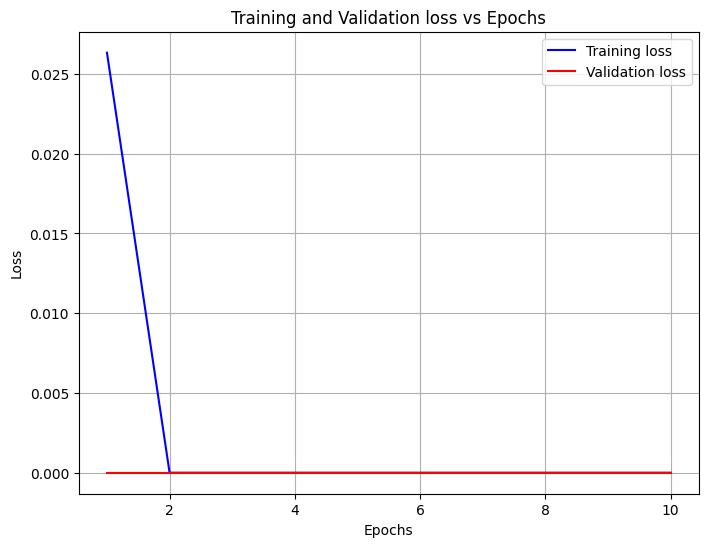

In [147]:
#Visualizing the model performance
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(range(1,len(train_losses)+1),train_losses,label="Training loss",color="Blue")
plt.plot(range(1,len(val_losses)+1),val_losses,label="Validation loss",color="Red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

## Estimating model performance

In [148]:
all_scores=[]
all_labels=[]
all_pids=[]
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch=batch.to(device)
        out=model(batch)
        probs=torch.sigmoid(out).view(-1)
        labels=batch.edge_label.view(-1)
        pids=batch.y[batch.batch]
        edge_pids=pids[batch.edge_index[0]]
        
        all_scores.append(probs.cpu())
        all_labels.append(labels.cpu())
        all_pids.append(edge_pids.cpu())

In [149]:
scores=torch.cat(all_scores).numpy()
labels=torch.cat(all_labels).numpy()
pids=torch.cat(all_pids).numpy()

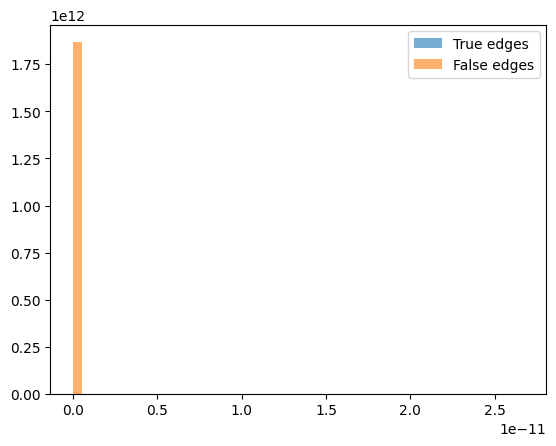

In [158]:
#Plotting for all particles
import matplotlib.pyplot as plt

true_scores=scores[labels==1]
false_scores=scores[labels==0]

plt.figure()

plt.hist(true_scores,bins=50,alpha=0.6,label="True edges",density=True)
plt.hist(false_scores,bins=50,alpha=0.6,label="False edges",density=True)
plt.legend(loc='best')
#plt.yscale("log")

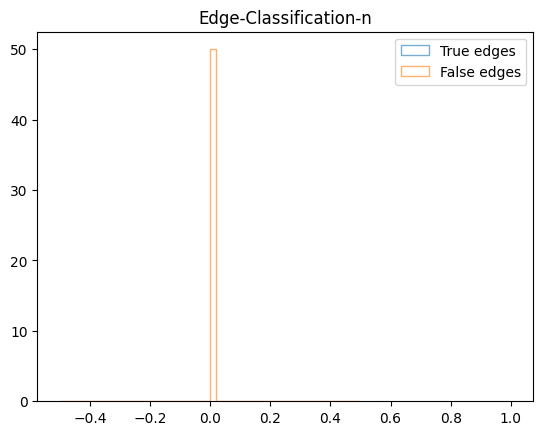

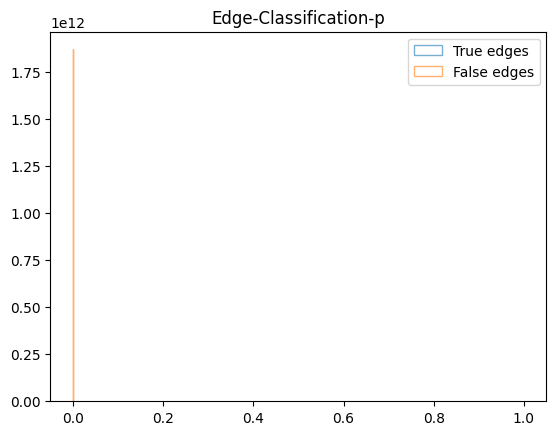

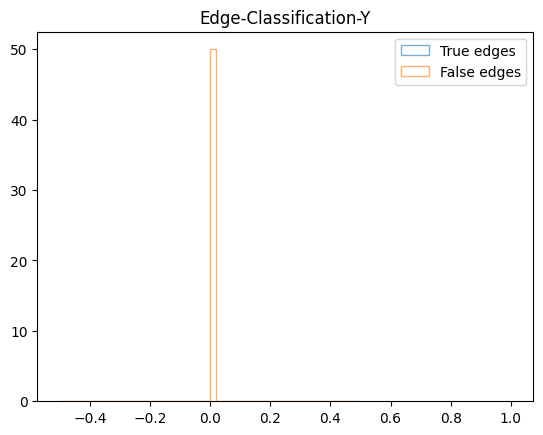

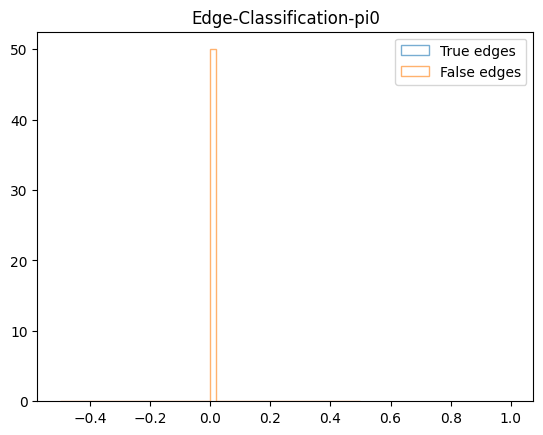

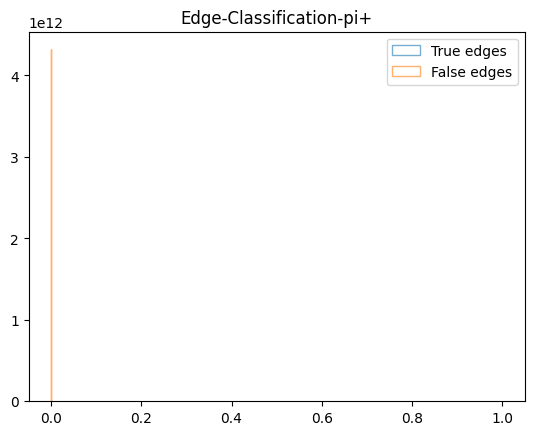

In [182]:
# For each particle
particle_ids
for pname,pid in particle_ids.items():
    mask=(pids==pid)
    pid_scores=scores[mask]
    pid_labels=labels[mask]
    true_scores=pid_scores[pid_labels==1]
    false_scores=pid_scores[pid_labels==0]
    plt.figure()
    plt.hist(true_scores,bins=50,histtype='step',alpha=0.6,label="True edges",density=True)
    plt.hist(false_scores,bins=50,histtype='step',alpha=0.6,label="False edges",density=True)
    plt.legend(loc='best')
    plt.title(f"Edge-Classification-{pname}")
    plt.show()

In [151]:
print(np.isnan(node_features).sum())

0


In [152]:
print(torch.isnan(out).sum())

tensor(0)


In [153]:
print(len(scores[labels == 1]), len(scores[labels == 0]))

0 2901952
